# 06 · Model comparison — and the leakage lesson

The payoff. All 11 models (incl. the EC2 baseline) were scored on **identical folds**, with metrics in physical units (MPa). We compare two validation protocols:

1. **Random** repeated 5×5 K-fold — what the original study effectively used.
2. **Researcher-held-out** GroupKFold — whole labs held out, the honest test of generalization to a *new* experiment.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import punching_shear as ps
REPO = Path(ps.__file__).resolve().parent.parent
RESULTS = REPO / 'results'
ds = ps.load_dataset()
print(f'{len(ds)} tests, {ds.groups.nunique()} researchers, features={ds.feature_names}')

336 tests, 55 researchers, features=['d', 'col_area', 'rho_l', 'fcm_cyl', 'u0_perim']


In [2]:
rand = pd.read_csv(RESULTS/'metrics_random_kfold.csv').set_index('model')
grp  = pd.read_csv(RESULTS/'metrics_grouped_kfold.csv').set_index('model')
cmp = pd.DataFrame({'RMSE random':rand.rmse_mean,'R2 random':rand.r2_mean,
                    'RMSE grouped':grp.rmse_mean,'R2 grouped':grp.r2_mean}).round(3)
cmp = cmp.sort_values('RMSE random')
display(cmp)

,RMSE random,R2 random,RMSE grouped,R2 grouped
model,,,,
Random Forest,0.234,0.787,0.317,0.579
SVR (RBF),0.252,0.752,0.362,0.334
NLR (d x fcm),0.285,0.680,0.317,0.575
ElasticNet,0.288,0.674,0.316,0.578
Lasso,0.288,0.674,0.316,0.576
OLS,0.288,0.675,0.315,0.579
Ridge,0.288,0.675,0.315,0.581
SVR (linear),0.288,0.675,0.316,0.574
Decision Tree,0.307,0.632,0.372,0.423


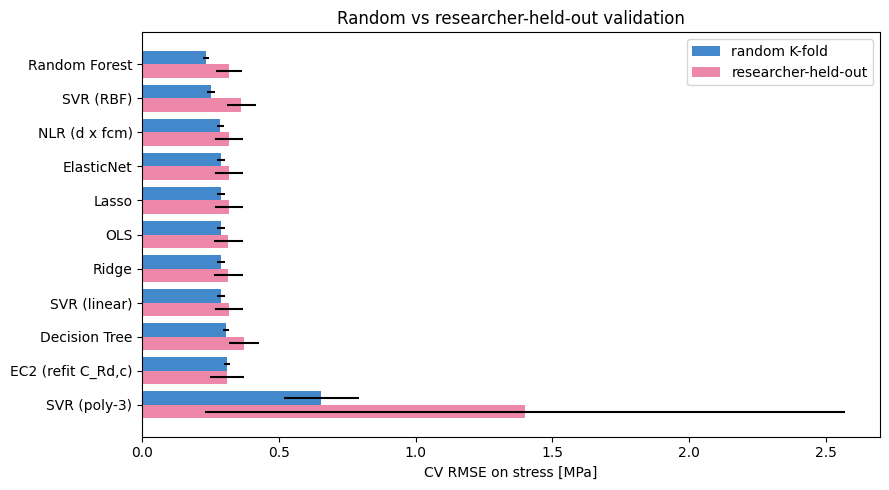

In [3]:
fig,ax=plt.subplots(figsize=(9,5))
order=cmp.index
y=np.arange(len(order)); w=.4
ax.barh(y-w/2, rand.loc[order,'rmse_mean'], w, xerr=rand.loc[order,'rmse_ci95'], label='random K-fold', color='#48c')
ax.barh(y+w/2, grp.loc[order,'rmse_mean'], w, xerr=grp.loc[order,'rmse_ci95'], label='researcher-held-out', color='#e8a')
ax.set_yticks(y); ax.set_yticklabels(order); ax.invert_yaxis(); ax.set_xlabel('CV RMSE on stress [MPa]'); ax.legend(); ax.set_title('Random vs researcher-held-out validation'); plt.tight_layout(); plt.show()

### Paired significance (random-split out-of-fold errors)

In [4]:
sig = pd.read_csv(RESULTS/'paired_significance.csv')
display(sig.round(4))

,a,b,statistic,p_value,median_abs_err_diff,a_better_frac,n
0,Random Forest,"EC2 (refit C_Rd,c)",15976.0,0.0000,-0.0473,0.6518,336
1,Random Forest,OLS,18239.0,0.0000,-0.0248,0.6131,336
2,Random Forest,NLR (d x fcm),18832.0,0.0000,-0.0314,0.6220,336
3,Random Forest,Lasso,18221.0,0.0000,-0.0251,0.6161,336
4,Random Forest,Ridge,18244.0,0.0000,-0.0244,0.6190,336
5,Random Forest,ElasticNet,18213.0,0.0000,-0.0248,0.6220,336
6,Random Forest,SVR (linear),18130.0,0.0000,-0.0235,0.6220,336
7,Random Forest,SVR (poly-3),10236.0,0.0000,-0.0911,0.7292,336
8,Random Forest,SVR (RBF),26958.0,0.4487,0.0001,0.5000,336
9,Random Forest,Decision Tree,17983.0,0.0000,-0.0288,0.6101,336


## The lesson

- Under **random** K-fold, Random Forest and SVR-RBF clearly beat EC2 (Wilcoxon p < 1e-8) — this reproduces the original *“ML beats Eurocode”* story.
- Under **researcher-held-out** CV the ranking **collapses**: **EC2 is the best model**, every ML model falls back to the linear baseline, and SVR-RBF and the trees degrade sharply.

The apparent ML superiority was largely **lab leakage** — with many specimens per researcher, a random split lets flexible models memorize lab-specific offsets. The honest conclusion: on this dataset, **no ML model reliably out-generalizes the Eurocode 2 formula** to a new laboratory. The value of the ML study is interpretive (it identifies `rho_l`/`fcm` as the drivers and rules out column profile), not a replacement for the code formula.